<a href="https://colab.research.google.com/github/AncaraniJuanDiego/IAModelosDeRegresi-n./blob/main/NB01_MLP_sklearn_RedesNuronales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 01 — Primeras redes neuronales con Scikit-learn

**Pontificia Universidad Católica Argentina – Campus Rosario**
Licenciatura en Ciencias de Datos · Inteligencia Artificial y Aprendizaje Automático II · 2026
**Unidad 1 · Semana 1 · Clase 2**

---

## Objetivos de la clase

Al terminar este notebook vas a poder:

1. Entrenar un perceptrón multicapa (`MLPClassifier`) con la misma API de Scikit-learn que ya conocés de asignaturas previas.
2. Comparar su desempeño contra un modelo clásico (Random Forest) sobre el mismo problema.
3. Interpretar la curva de pérdida del entrenamiento.
4. Identificar el efecto de los hiperparámetros principales: arquitectura, tasa de aprendizaje e iteraciones.

> **Idea central de la clase:** una red neuronal no es un objeto exótico — es un estimador más de Scikit-learn, con `fit` y `predict`. Lo nuevo no es la API: es lo que pasa adentro. Y sobre el final vamos a empezar a ver por qué esta herramienta nos va a quedar chica.

## 1. Setup

Ejecutá la celda siguiente. En Colab no hace falta instalar nada: todo viene preinstalado.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

RANDOM_STATE = 42  # reproducibilidad: mismo resultado en todas las corridas
np.random.seed(RANDOM_STATE)

print("Setup listo.")

Setup listo.


## 2. El dataset: Fashion-MNIST

Trabajamos con **Fashion-MNIST**: 70.000 imágenes en escala de grises de 28×28 píxeles, con 10 clases de prendas de ropa. Es el reemplazo moderno del clásico MNIST de dígitos: mismo formato, problema más difícil.

Cada imagen llega **aplanada** como un vector de 784 valores (28×28). Para Scikit-learn eso es simplemente una fila con 784 features.

La descarga desde OpenML tarda un par de minutos la primera vez. Usamos un subconjunto de 12.000 imágenes para que los experimentos de la clase corran rápido.

In [ ]:
# Descarga (tarda la primera vez; queda cacheado)
X_full, y_full_ori = fetch_openml("Fashion-MNIST", version=1, return_X_y=True, as_frame=False, parser="auto")
y_full = y_full_ori.astype(int)

# Subconjunto de trabajo para la clase
N = 12000
idx = np.random.choice(len(X_full), size=N, replace=False)
X, y = X_full[idx], y_full[idx]

CLASES = ["Remera", "Pantalón", "Buzo", "Vestido", "Abrigo",
          "Sandalia", "Camisa", "Zapatilla", "Bolso", "Botín"]

print(f"X: {X.shape}  |  y: {y.shape}  |  valores de píxel: [{X.min():.0f}, {X.max():.0f}]")

X: (12000, 784)  |  y: (12000,)  |  valores de píxel: [0, 255]


### 2.1. Mirar los datos antes de modelar

Regla que no cambia de las asignaturas previas a esta materia: **nunca entrenes sobre datos que no miraste.**

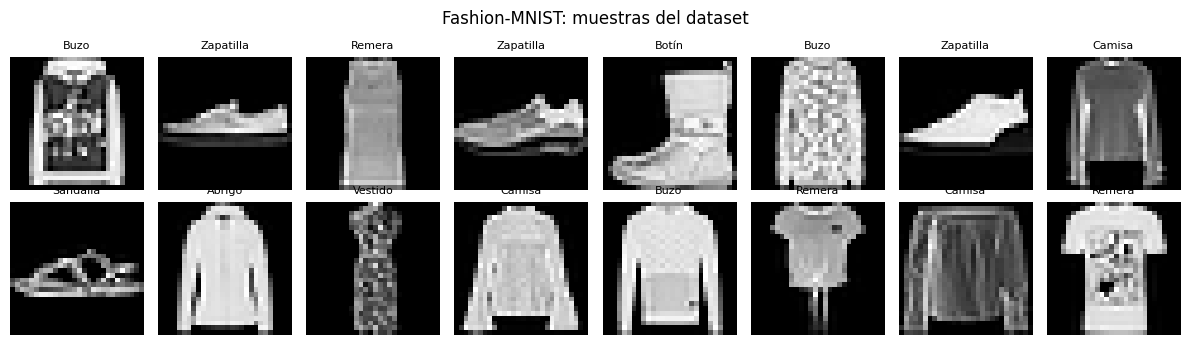

In [ ]:
fig, axes = plt.subplots(2, 8, figsize=(12, 3.5))
for ax, i in zip(axes.ravel(), range(16)):
    ax.imshow(X[i].reshape(28, 28), cmap="gray")
    ax.set_title(CLASES[y[i]], fontsize=8)
    ax.axis("off")
plt.suptitle("Fashion-MNIST: muestras del dataset")
plt.tight_layout()
plt.show()

### 2.2. Partición y escalado

Dos decisiones de preprocesamiento:

- **Partición estratificada** train/test (80/20), como siempre.
- **Escalado a [0, 1]** dividiendo por 255. Para Random Forest esto es indiferente (los árboles parten por umbrales, el rango no importa). Para la red neuronal es **crítico**: el descenso de gradiente se comporta mucho mejor con entradas en rangos chicos y homogéneos. En la clase 3 profundizamos el porqué.

**Ejercicio 2.1** — Completá la partición y el escalado.

Partición Estratificada:
Intenta conservar en train y en test la distribución original de las clases.

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

# TODO Ejercicio 2.1
# 1) Particioná X, y en train/test (80/20), estratificado, con random_state=RANDOM_STATE
# 2) Escalá ambos conjuntos al rango [0, 1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

# Escalado
X_train = X_train / 255.0
X_test = X_test / 255.0

print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (9600, 784) | Test: (2400, 784)


## 3. Baseline: Random Forest (el puente desde lo que ya sabés)

Antes de tocar una red neuronal, establecemos un **baseline** con un modelo que ya dominás. Esto también es una regla permanente: *ningún modelo complejo se justifica sin un baseline simple contra el cual compararlo.*

In [ ]:
t0 = time.perf_counter()
rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
t_rf = time.perf_counter() - t0

acc_rf = accuracy_score(y_test, rf.predict(X_test))
print(f"Random Forest — accuracy: {acc_rf:.4f} | tiempo de entrenamiento: {t_rf:.1f} s")

Random Forest — accuracy: 0.8608 | tiempo de entrenamiento: 13.1 s


## 4. La primera red neuronal: `MLPClassifier`

Un **perceptrón multicapa (MLP)** con una capa oculta de 128 neuronas. Fijate que la API es *exactamente la misma*: instanciar, `fit`, `predict`.

Los hiperparámetros que nos importan hoy:

| Parámetro | Qué controla |
|---|---|
| `hidden_layer_sizes` | Arquitectura: cantidad de capas ocultas y neuronas por capa |
| `learning_rate_init` | Tasa de aprendizaje: tamaño del paso del descenso de gradiente |
| `max_iter` | Cantidad máxima de épocas (pasadas completas por los datos) |
| `activation` | Función de activación de las capas ocultas (`relu` por defecto) |

In [ ]:
t0 = time.perf_counter()
mlp = MLPClassifier(
    hidden_layer_sizes=(128,),
    learning_rate_init=0.00001,
    max_iter=30,
    random_state=RANDOM_STATE,
)
mlp.fit(X_train, y_train)
t_mlp = time.perf_counter() - t0

acc_mlp = accuracy_score(y_test, mlp.predict(X_test))
print(f"MLP — accuracy: {acc_mlp:.4f} | tiempo: {t_mlp:.1f} s")
print(f"(Baseline RF: {acc_rf:.4f} en {t_rf:.1f} s)")

MLP — accuracy: 0.7196 | tiempo: 11.9 s
(Baseline RF: 0.8608 en 13.1 s)


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(


### 4.1. La curva de pérdida

Durante `fit`, el MLP fue guardando el valor de la **función de pérdida** en cada época en el atributo `loss_curve_`. Esa curva es el electrocardiograma del entrenamiento: la vamos a mirar durante todo el semestre.

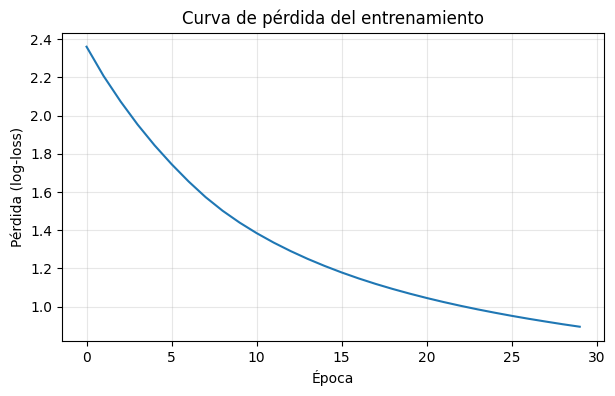

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(mlp.loss_curve_)
plt.xlabel("Época")
plt.ylabel("Pérdida (log-loss)")
plt.title("Curva de pérdida del entrenamiento")
plt.grid(alpha=0.3)
plt.show()

## 5. Experimento: el efecto de los hiperparámetros

**Ejercicio 5.1** — Entrená tres MLP variando solo la **tasa de aprendizaje**: `0.0001`, `0.001` y `0.1` (mismos demás parámetros). Graficá las tres curvas de pérdida juntas y respondé:

a) ¿Cuál converge mejor?
b) ¿Qué le pasa a la de `0.1`? ¿Por qué?
c) ¿Qué costo tiene la de `0.0001`?

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(


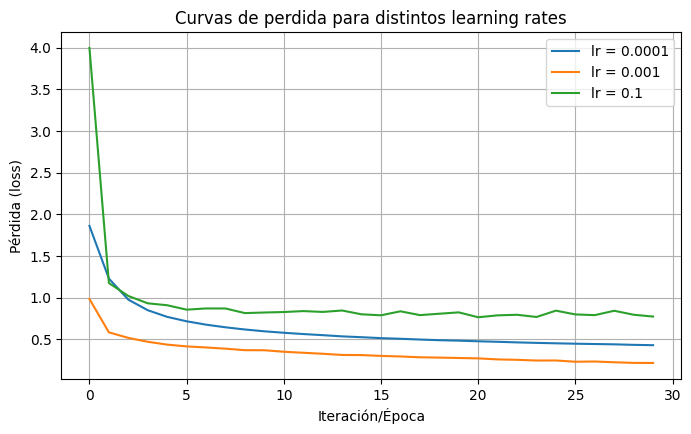

In [ ]:
# TODO Ejercicio 5.1
# Entrená tres MLP con learning_rate_init en [0.0001, 0.001, 0.1]
# (hidden_layer_sizes=(128,), max_iter=30, random_state=RANDOM_STATE)
# Guardalos en el diccionario `resultados` con el lr como clave.

resultados = {}
for lr in [0.0001, 0.001, 0.1]:
    m = MLPClassifier(
        hidden_layer_sizes = (128, ),
        learning_rate_init = lr,
        max_iter = 30,
        random_state = RANDOM_STATE
    )

    m.fit(X_train, y_train)
    resultados[lr] = m


# Graficá las tres curvas de pérdida en una sola figura, con leyenda.
plt.figure(figsize=(8, 4.5))

for lr, m in resultados.items():
  plt.plot(m.loss_curve_, label = f'lr = {lr}')

plt.xlabel('Iteración/Época')
plt.ylabel('Pérdida (loss)')
plt.title('Curvas de perdida para distintos learning rates')
plt.legend()
plt.grid(True)
plt.show()

# Respondé en esta celda como comentarios:

# a) ¿Que learning rate converge mas rapido?
# b) ¿Cual tiene el menor loss al final?
# c) ¿Que ocurre con learning_rate_init = 0.1?

¿Que pasa con el for?

Hace 3 vueltas con (1ra: 0.0001; 2da: 0.001; 3ra: 0.1)

* en cada vuelta se crea una red nueva y se entrena, luego se guarda.

**Ejercicio 5.2** — Ahora fijá `learning_rate_init=0.001` y variá la **arquitectura**: `(32,)`, `(128,)`, `(256, 128)`. Para cada una reportá accuracy en test, tiempo de entrenamiento y cantidad total de parámetros de la red.

*Pista para contar parámetros:* cada capa densa que conecta $n$ entradas con $m$ salidas tiene $n \times m$ pesos $+ m$ sesgos. Podés verificar tu cuenta con `sum(w.size for w in modelo.coefs_) + sum(b.size for b in modelo.intercepts_)`.

In [ ]:
# TODO Ejercicio 5.2
# Para cada arquitectura en [(32,), (128,), (256, 128)]:
#   - entrená un MLP (lr=0.001, max_iter=30, random_state=RANDOM_STATE)
#   - medí tiempo de entrenamiento con time.perf_counter()
#   - reportá accuracy en test y cantidad total de parámetros

for arq in [(32,), (128,), (256, 128)]:

  m = MLPClassifier(
      hidden_layer_sizes = arq,
      learning_rate_init = 0.001,
      max_iter = 30,
      random_state = RANDOM_STATE
  )

  time_0 = time.perf_counter()
  m.fit(X_train, y_train)
  tiempo = time.perf_counter() - time_0

  y_pred = m.predict(X_test)
  accuracy = accuracy_score(y_test, y_pred)
  parametros = sum(w.size for w in m.coefs_) + sum(b.size for b in m.intercepts_)

  print(f'Arquitectura: {arq}')
  print(f'Tiempo de entrenamiento: {tiempo:.2f} segundos.')
  print(f'Accuracy en test: {accuracy:.4f}')
  print(f'Cantidad total de parametros: {parametros}')
  print()

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(


Arquitectura: (32,)
Tiempo de entrenamiento: 6.98 segundos.
Accuracy en test: 0.8508
Cantidad total de parametros: 25450



/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(


Arquitectura: (128,)
Tiempo de entrenamiento: 12.75 segundos.
Accuracy en test: 0.8617
Cantidad total de parametros: 101770

Arquitectura: (256, 128)
Tiempo de entrenamiento: 28.47 segundos.
Accuracy en test: 0.8625
Cantidad total de parametros: 235146



/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(


## 6. Evaluación honesta: ¿dónde se equivoca la red?

La accuracy global esconde información. La **matriz de confusión** muestra entre qué clases se confunde el modelo.

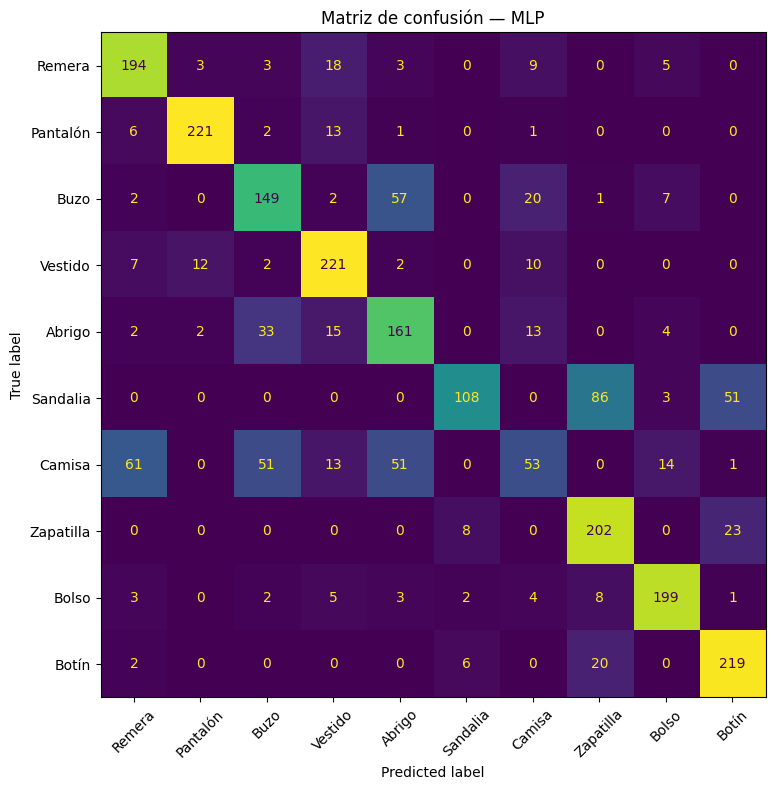

              precision    recall  f1-score   support

      Remera       0.70      0.83      0.76       235
    Pantalón       0.93      0.91      0.92       244
        Buzo       0.62      0.63      0.62       238
     Vestido       0.77      0.87      0.82       254
      Abrigo       0.58      0.70      0.63       230
    Sandalia       0.87      0.44      0.58       248
      Camisa       0.48      0.22      0.30       244
   Zapatilla       0.64      0.87      0.73       233
       Bolso       0.86      0.88      0.87       227
       Botín       0.74      0.89      0.81       247

    accuracy                           0.72      2400
   macro avg       0.72      0.72      0.70      2400
weighted avg       0.72      0.72      0.70      2400



In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay.from_estimator(
    mlp, X_test, y_test, display_labels=CLASES,
    xticks_rotation=45, colorbar=False, ax=ax
)
plt.title("Matriz de confusión — MLP")
plt.tight_layout()
plt.show()

print(classification_report(y_test, mlp.predict(X_test), target_names=CLASES))

**Para discutir:** ¿qué pares de clases se confunden más? ¿Tiene sentido *visual* esa confusión (volvé a las imágenes de la sección 2.1)? ¿Alcanzaría con más neuronas para resolverla, o el problema es que el modelo ve 784 números sueltos y no una imagen?

### **Pares de clases en las que el modelo se confunde más:**

* **Camisa (f1_score = 0.3)** → mucho volumen de falsos positivos. Predice otra clase (ej: remera-buzo-vestido-abrigo), cuando en realidad era la prenda camisa.

* **Sandalia (f1_score = 0.58)** → mucho volumen de falsos positivos. El modelo las confunde demasiado con zapatillas-botines.

      -- 86/248 clasificó a zapatilla cómo sandalia y 51/248 clasificó botín.

### **Sentido visual de la confusión con la imagen de la sección 2.1**

Si, tiene sentido por el gran parecido visual entre algunas prendas, por ejemplo:

camisa con: remera-abrigo-buzo. Las 4 clases tienen un diseño similar, aunque no sean iguales. Se ubican en el cuerpo de la persona, simulando una forma muy particular y confunda para el modelo.

Sandalia con: zapatilla-botin. Lo mismo que las prendas para el cuerpo, las 3 se ubican en el pie de la persona y con un diseño parecido, lo que confunde al modelo poder distinguirlas correctamente.

### **¿Alcanzaría con más neuronas para resolverla, o el problema es que el modelo ve 784 números sueltos y no una imagen?**

 La solución podría ser modificar las capas ocultas entre la entrada y la salida. Pasar de utilizar una sola, a multicapa. Por ejemplo:

* pasar de **[784 → 32 → 10]** → poco tiempo de carga, pero menor capacidad de generalización.

* a **[784 → 128 → 10] o [784 → (256,128) → 10]** → más tiempo, pero mejor capacitación.

Probablemente se mejore la capacidad del modelo y distinguirá mejor las prendas de ropa.




## 7. Cierre: lo que este enfoque no nos deja hacer

Hoy entrenaste tu primera red neuronal con tres líneas de código. Pero anotá lo que ya asoma:

- El entrenamiento fue **lento** comparado con Random Forest, y usó solo CPU.
- La red trata cada píxel como una feature independiente: **ignora la estructura espacial** de la imagen.
- No pudimos ver la pérdida *mientras* entrenaba, ni frenar a tiempo, ni guardar el mejor modelo intermedio: `fit` es una caja cerrada.

En la **clase 3** vamos a chocar deliberadamente contra estos límites y medirlos. Esa frustración tiene nombre y solución: se llama **Keras**, y es el tema central del resto de la materia.

---

### Checklist de salida

- [ ] Entrené un MLP con la API de Scikit-learn y le gané (¿o no?) al baseline de Random Forest.
- [ ] Sé leer una curva de pérdida y explicar qué pasa con lr muy alto y muy bajo.
- [ ] Puedo estimar la cantidad de parámetros de una red densa.
- [ ] Identifiqué en la matriz de confusión los pares de clases problemáticos.

**Material de consulta:** Kneusel, *Practical Deep Learning* (capítulos de datasets y de modelos clásicos); documentación de `MLPClassifier` en scikit-learn.org.